In [2]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import scipy

## Problem 1 {-}
Consider a constant matrix and a vector function given by
$$
A = \begin{bmatrix} 1 & 2 \\ 2 & -2 \end{bmatrix}, \qquad f(t) = \begin{bmatrix} 2 \\ 3t^{2} \end{bmatrix}
$$

### 1. {-}
Compute $e^{At}$.

To compute the value, the eigenvalues and vectors must first be found. This is done using the sympy python library.

In [3]:
A = sp.Matrix([[1,2],[2,-2]])
r = A.rank()
lam2, lam1 = A.eigenvals()
vec1 = A.eigenvects()[0][2][0]
vec2 = A.eigenvects()[1][2][0]
print(f"One of the eigenvalues is {lam1}, which has the corresponding eigenvector")
display(vec1)
print(f"The other eigenvalue is {lam2}, and has the corresponding eigenvector")
display(vec2)

One of the eigenvalues is -3, which has the corresponding eigenvector


Matrix([
[-1/2],
[   1]])

The other eigenvalue is 2, and has the corresponding eigenvector


Matrix([
[2],
[1]])

These can be used to find the eigenvalue solutions of $x' = Ax$ as described in theorem 5.2.1.

In [4]:
t = sp.Symbol("t")
x1 = sp.exp(lam1*t) * vec1
x2 = sp.exp(lam2*t) * vec2

print(f"The solution for the eigenvalue {lam1} is")
display(x1)
print(f"The solution for the eigenvalue {lam2} is")
display(x2)

The solution for the eigenvalue -3 is


Matrix([
[-exp(-3*t)/2],
[   exp(-3*t)]])

The solution for the eigenvalue 2 is


Matrix([
[2*exp(2*t)],
[  exp(2*t)]])

These solutions lead to the following fundamental matrix for the equation

In [5]:
Phi = sp.Matrix([[x1,x2]])
Phi

Matrix([
[-exp(-3*t)/2, 2*exp(2*t)],
[   exp(-3*t),   exp(2*t)]])

The value of $e^{At}$ can finally be computed following theorem 5.6.3, which results in the following

In [6]:
eAt = Phi * Phi.subs(t,0).inv()
eAt

Matrix([
[  4*exp(2*t)/5 + exp(-3*t)/5, 2*exp(2*t)/5 - 2*exp(-3*t)/5],
[2*exp(2*t)/5 - 2*exp(-3*t)/5,   exp(2*t)/5 + 4*exp(-3*t)/5]])

### 2. {-}
Solve the differential equation $x' = Ax + f(t)$ with initial value $x(0) = [1 \; \; 0]^{T}$ using the variations of parameters approach.

Theorem 5.7.1 can be used as long as $P(t)$ (which in this case is $A$) and $f(t)$ are continuous. Since $A$ is constant and therefore continuous, and $f(t)$ is given as a continuous function of $t$, this theorem can be used. Solving with this approach requires the general solution to the complementary homogeneous equation. This solution can be found using theorem 5.6.2 by combining the value of $e^{At}$ from the previous section with the given initial value. This results in the following solution

In [7]:
a = 0
xa = sp.Matrix([[1,0]]).T
s = sp.Symbol("s")
f = sp.Matrix([[2, 3*t**2]]).T
xc = Phi * Phi.subs(t, a).inv() * xa
xc

Matrix([
[  4*exp(2*t)/5 + exp(-3*t)/5],
[2*exp(2*t)/5 - 2*exp(-3*t)/5]])

Now a particular solution must be found using the variation of parameters formula. Since any integration constant is sufficient for the particular solution, the particular solution where $x_{p}(a) = 0$ is chosen to get an integration constant of 0. This is true if the integration limits are from $a$ to $a$ at the point $t=a$. The particular solution is then defined using the fundamental matrix as
$$
x_{p}(t) = \Phi(t) \int_{a}^{t} \Phi^{-1}(s) f(s) \, ds
$$
Calculating this with sympy results in

In [8]:
xp = Phi * sp.integrate(Phi.subs(t, s).inv() * f.subs(t, s), (s, a, t))
xp.simplify()

Matrix([
[   -t**2 - t/3 + 11*exp(2*t)/10 - 19/18 - 2*exp(-3*t)/45],
[t**2/2 - 5*t/6 + 11*exp(2*t)/20 - 23/36 + 4*exp(-3*t)/45]])

The sum of these two solutions must then be the general solution to the initial value problem

In [9]:
xt = xc + xp
sp.simplify(xt)

Matrix([
[    -t**2 - t/3 + 19*exp(2*t)/10 - 19/18 + 7*exp(-3*t)/45],
[t**2/2 - 5*t/6 + 19*exp(2*t)/20 - 23/36 - 14*exp(-3*t)/45]])

$\pagebreak$

### 3. {-}
Explain how the solution changes if the system is started from a different $x_{0}$. Include a phase plane portrait with (at least) two examples of different $x_{0}$ values.

To analyze what difference the initial value $x_{0}$ makes to the solution, the solutions of various initial values are computed and plotted, including a plot for the initial value $x(0) = [1 \; \; 0]^{T}$. When plotting, the timeinterval used is $-5 < t < 5$ since values of $t$ any lower or higher do not provide further information. Negative time values do not physically make sense but it makes for a better visualization. Since this is a pure mathematical analysis, they are still used. The plots can be seen below.

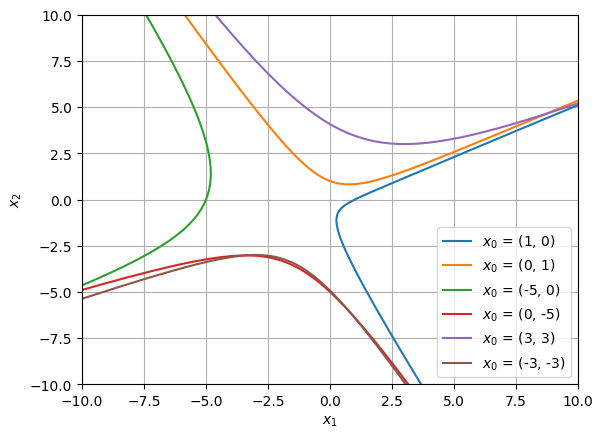

In [10]:
def sol(x0):
    return eAt * x0 + xp

x0_list = sp.Matrix([   [1,0,-5,0,3,-3],
                        [0,1,0,-5,3,-3],])

time = np.linspace(-5,5,300)

for i in range(x0_list.shape[1]):
    x0 = x0_list[:,i]
    x1 = sp.lambdify(t, sol(x0)[0,:], "numpy")
    x2 = sp.lambdify(t, sol(x0)[1,:], "numpy")

    x1sol = np.ravel(x1(time))
    x2sol = np.ravel(x2(time))

    plt.plot(x1sol, x2sol, label=f"$x_0$ = ({x0[0]}, {x0[1]})")

plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.grid()
plt.xlim([-10,10])
plt.ylim([-10,10])
plt.legend()
plt.show()

It can be seen that different initial values do not change the general shape of the solutions which is either a curve that avoids some saddle point or a line which intersects some saddle point. It can however be seen that the solution curves of different initial values are able to intersect each other. This means that a change in initial value can result in a change of the critical points associated with the system of the solution.

$\pagebreak$

## Problem 2 {-}
Consider the constant matrix given by
$$
A = \begin{bmatrix} 1 & 0 & 0 \\ 1 & 3 & 1 \\ -2 & -4 & -1 \end{bmatrix}
$$

### 1. {-}
Compute the eigenvalues and (generalized) eigenvectors of A.

The python sympy library is used to compute the eigenvalue of $A$. The eigenvalue is computed to be

In [11]:
A = sp.Matrix([[1,0,0], [1,3,1], [-2,-4,-1]])

lam = list(A.eigenvals().keys())[0]
lam

1

Since $A$ has a rank of 3, but only one eigenvalue. The multiplicity of this eigenvalue is 3. To find the eigenvector the equation $(A - \lambda I_{3})v = \vec{0}$ is solved

\begin{align*}
A - \lambda I_{3} &= \begin{bmatrix}
1-1 & 0 & 0 \\
1 & 3-1 & 1 \\
-2 & -4 & -1-1
\end{bmatrix}\\
&= \begin{bmatrix}
0 & 0 & 0 \\
1 & 2 & 1 \\
-2 & -4 & -2
\end{bmatrix}\\
&\sim_{R_{2} \to R_{2} + 2R_{1}}\\
&\begin{bmatrix}
0 & 0 & 0 \\
1 & 2 & 1 \\
0 & 0 & 0
\end{bmatrix}
\end{align*}

Now a solution to the following equation has to be found
$$
x + 2y + z = 0
$$

Since there are 2 free variables and one dependent variable in this case, it is known that the corresponding eigenvectors span a 2-dimensional space. Two independent solutions could be

$$
u_{1} = 
\begin{bmatrix}
-2 \\
1 \\
0
\end{bmatrix}
$$

$$
v_{1} = 
\begin{bmatrix}
0 \\
1 \\
-2
\end{bmatrix}
$$

$\pagebreak$

Any other solution for the eigenvalue would be a linear combination of the two eigenvectors. Since the eigenvalue has a multiplicity of 3 but only 2 eigenvectors, it has a defect of $d=1$, meaning it must be possible to find a length 2 chain of generalized eigenvectors associated with the eigenvalue. The eigenvector $v_{1}$ is chosen to be the ordinary eigenvector of the chain, meaning that last vector must satisfy the equation $(A - \lambda I_{3})v_{2} = v_{1}$. Looking at the matrix
$$
A - \lambda I_{3} = \begin{bmatrix}
0 & 0 & 0 \\
1 & 2 & 1 \\
-2 & -4 & -2
\end{bmatrix}
$$
it can be seen that $v_{1}$ is in the column space of the matrix (column 2 if zero-indexed). This means that the last generalized eigenvector in the chain must be
$$
v_{2} = \begin{bmatrix} 0 \\ 0 \\ 1 \end{bmatrix}
$$

### 2. {-} 
Find the three solutions, $x_{1}(t)$, $x_{2}(t)$, and $x_{3}(t)$ of $x' = Ax$. Show that the solutions are linearly independent.

The first solution $x_{1}(t)$ can be found with the $u_{1}$ using Theorem 5.2.1. The last two independent solutions are found using the second part of the defective multiplicity 2 eigenvalue algorithm. This can be done even though the eigenvalue had a multiplicity of 3, since it only had a defect of 1, meaning that there was only a chain of length 2, which is what the second part of the algorithm solves for. The three solution are computed using the sympy library

In [12]:
u1 = sp.Matrix([[-2,1,0]]).T
v1 = sp.Matrix([[0,1,-2]]).T
v2 = sp.Matrix([[0,0,1]]).T

t = sp.symbols("t")

x1 = u1 * sp.exp(lam*t)
x2 =  v1 * sp.exp(lam*t)
x3 = sp.expand((v1*t + v2) * sp.exp(lam*t))

print("The first solution x1(t) is")
display(x1)
print("The second solution x2(t) is")
display(x2)
print("The third solution x3(t) is")
display(x3)

The first solution x1(t) is


Matrix([
[-2*exp(t)],
[   exp(t)],
[        0]])

The second solution x2(t) is


Matrix([
[        0],
[   exp(t)],
[-2*exp(t)]])

The third solution x3(t) is


Matrix([
[                   0],
[            t*exp(t)],
[-2*t*exp(t) + exp(t)]])

To check whether the three solutions are linearly independent, they are combined into a matrix, where each column is one of the three solutions. If the row echelon form of this matrix has a pivot all solutions are linearly independent. The matrix looks as follows

In [13]:
X = sp.Matrix([[x1,x2,x3]])
X

Matrix([
[-2*exp(t),         0,                    0],
[   exp(t),    exp(t),             t*exp(t)],
[        0, -2*exp(t), -2*t*exp(t) + exp(t)]])

Using matrix row operations the following result is obtained

In [14]:
X[1,:] += 1/2 * X[0,:]
X[2,:] += 2 * X[1,:]
X

Matrix([
[-2*exp(t),      0,        0],
[        0, exp(t), t*exp(t)],
[        0,      0,   exp(t)]])

Since every row has a pivot, the three solutions must be linearly independent.

### 3. {-} 
Solve the differential equation $x' = Ax$ with initial value $x(0) = [1 \; \; 0 \; \; 0]^{T}$.

Since it is a homogeneous differential equation, the solution will be determined as $x(t) = e^{At} x_{0}$, which is computed the same way as in problem 1.1. The solution is then

In [15]:
Phi = sp.Matrix([[x1, x2, x3]])
eAt = Phi * Phi.subs(t,0).inv()
x0 = sp.Matrix([[1,0,0]]).T
xt = eAt * x0
xt

Matrix([
[     exp(t)],
[   t*exp(t)],
[-2*t*exp(t)]])

### 4. {-} 
Does the solution to the initial value problem pass through the point $x_{m} = [2 \; \; 2 \; \; 3]^{T}$?

To find out whether the solution passes through the point, the value of $t$ that should return the point is found. When looking at the first coordinate of the solution and point, an equation can be constructed and solved to find the following value of $t$

\begin{align*}
e^{t} &= 2\\
t &= \ln(2)
\end{align*}

Inserting this value of $t$ into the solution gives the following point

In [16]:
sp.simplify(xt.subs(t,sp.ln(2)))

Matrix([
[       2],
[  log(4)],
[-log(16)]])

Since the result does not match the given point in any other coordinate than the first, the solution does not pass through the point.

$\pagebreak$

## Problem 3 {-}
Consider two second order systems given by

\begin{align*}
x'' + 2x' + 400x &= 0\\
y'' + 3y' + 400y &= 0
\end{align*}

### 1. {-} 
Classify the two systems and account for similarities and differences between them. What happens to the two systems if they are started from rest and unit offset at $t = 0$?

Both systems are described with homogeneous second order differential equations. Since they are homogeneous and of this form, they can both be described as mass spring dashpot systems with no contribution from external forces. The first and last term of the systems are identical, which means that they have the same natural frequency of
$$
\omega_{0} = \sqrt{\frac{400}{1}} = 20
$$

For the same reason they also share the same critical damping value of
$$
c_{cr} = \sqrt{4 \cdot 400 \cdot 1} = 40
$$

Both systems are underdamped, but due to the differences in value, the system $x(t)$ is slightly more underdamped with a damping constant of 2 rather than the system $y(t)$, which has a damping constant of 3. This means that though both systems oscillate and decay toward equilibrium, $y(t)$ will decay at a faster rate than $x(t)$.

If the systems start at rest it means that their rate of change at time $t=0$ is
$$
x'(0) = y'(0) = 0
$$

With an initial unit offset 
$$
x(0) = y(0) = 1
$$

both systems would start to move toward equilibrium the instant after $t=0$ whereafter they would enter an oscillation while decaying as described before.

### 2. {-}
Next, assume that the two systems are affected by a coupling between them that is proportional to the displacement of each system. The model therefore becomes

\begin{align*}
x'' + 2x' + 400x + \alpha xy &= 0\\
y'' + 3y' + 400y + \alpha xy &= 0
\end{align*}

Due to the coupling, it is now necessary to use numerical methods to solve the differential equations.

Compute the solutions, $x(t)$ and $y(t)$ of the coupled differential equations for the case of $\alpha = 0.1$ where the systems are again started from rest and unit offset at $t = 0$. Plot the solutions and describe any changes to the solutions relative to the non-coupled $\alpha = 0$ case.

To compute the solutions, the equations first has to be converted into systems of first-order equations. This is done by defining the values 
$$
x_{1} = x, \quad x_{2} = x', \quad y_{1} = y, \quad y_{2} = y'
$$

With these definitions along with the definition $\alpha=0.1$, the equations become

\begin{align*}
x_{1}' &= x_{2}\\
x_{2}' &= -2 x_{2} - 400 x_{1} - 0.1 x_{1} y_{1}\\
y_{1}' &= y_{2}\\
y_{2}' &= -3 y_{2} - 400 y_{1} - 0.1 x_{1} y_{1}
\end{align*}

This is now solved numerically with the RK4 algorithm, which is done using the scipy library in python, whereafter it is plotted.

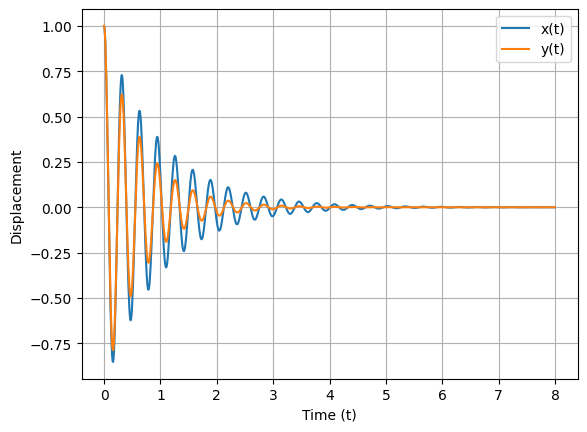

In [17]:
alpha = 0.1

# Coupled system of equations
def coupled_system(t, state):
    x1, x2, y1, y2 = state  # x, x', y, y'
    dx1_dt = x2
    dx2_dt = -2 * x2 - 400 * x1 - alpha * x1 * y1
    dy1_dt = y2
    dy2_dt = -3 * y2 - 400 * y1 - alpha * x1 * y1
    return [dx1_dt, dx2_dt, dy1_dt, dy2_dt]

# Initial conditions: x(0) = 1, x'(0) = 0, y(0) = 1, y'(0) = 0
initial_conditions = [1, 0, 1, 0]

# Time span for simulation
t_span = (0, 8)
t = np.linspace(t_span[0], t_span[1], 1000)

# Solve the system using solve_ivp
solution = scipy.integrate.solve_ivp(coupled_system, t_span, initial_conditions, t_eval=t, method='RK45')

# Extract results
t = solution.t
x = solution.y[0]
y = solution.y[2]

# Plot x(t)
plt.plot(t, x, label='x(t)')

# Plot y(t)
plt.plot(t, y, label='y(t)')

# Titles and labels
plt.xlabel('Time (t)')
plt.ylabel('Displacement')
plt.legend()
plt.grid()

To see the difference between this system and a decoupled system, the numerical difference between the two can be plotted.

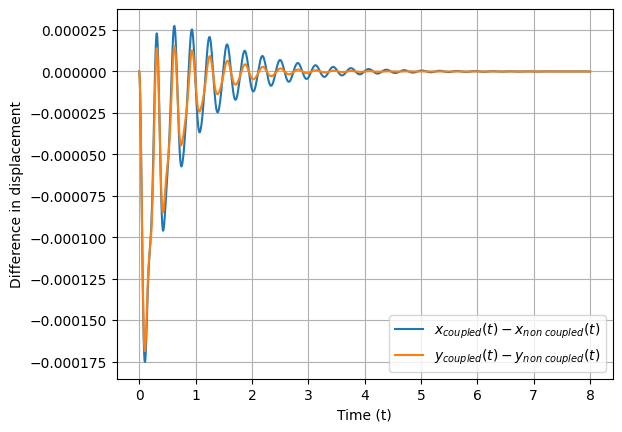

In [18]:
alpha = 0.1

# Coupled system of equations
def coupled_system(t, state):
    x1, x2, y1, y2 = state  # x, x', y, y'
    dx1_dt = x2
    dx2_dt = -2 * x2 - 400 * x1 - alpha * x1 * y1
    dy1_dt = y2
    dy2_dt = -3 * y2 - 400 * y1 - alpha * x1 * y1
    return [dx1_dt, dx2_dt, dy1_dt, dy2_dt]

def decoupled_system(t, state):
    x1, x2, y1, y2 = state  # x, x', y, y'
    dx1_dt = x2
    dx2_dt = -2 * x2 - 400 * x1
    dy1_dt = y2
    dy2_dt = -3 * y2 - 400 * y1
    return [dx1_dt, dx2_dt, dy1_dt, dy2_dt]

# Initial conditions: x(0) = 1, x'(0) = 0, y(0) = 1, y'(0) = 0
initial_conditions = [1, 0, 1, 0]

# Time span for simulation
t_span = (0, 8)
t = np.linspace(t_span[0], t_span[1], 1000)

# Solve the system using solve_ivp
coupled_solution = scipy.integrate.solve_ivp(coupled_system, t_span, initial_conditions, t_eval=t, method='RK45')
decoupled_solution = scipy.integrate.solve_ivp(decoupled_system, t_span, initial_conditions, t_eval=t, method='RK45')

# Extract results
t = solution.t
x = coupled_solution.y[0] - decoupled_solution.y[0]
y = coupled_solution.y[2] - decoupled_solution.y[2]

# Plot x(t)
plt.plot(t, x, label='$x_{coupled}(t) - x_{non\ coupled}(t)$')

# Plot y(t)
plt.plot(t, y, label='$y_{coupled}(t) - y_{non\ coupled}(t)$')

# Titles and labels
plt.xlabel('Time (t)')
plt.ylabel('Difference in displacement')
plt.legend()
plt.grid()

It can be seen that there is a sizable difference from the time interval $0 < t < 1.5$, whereafter the difference also oscillates and decays a bit alike the systems movement. The difference happens since the two systems are dependent on each other when coupled, and are independent when not. It then makes sense that the bigger either $x(t)$ or $y(t)$ is, the bigger the difference is between the coupled and non-coupled systems. The reason for the oscillation and decay toward zero in the difference is that even though the systems are different, they all decay toward equilibrium regardless of whether they are coupled or not.

### 3. {-}
What happens to the solutions if the first system is not started from unit offset, but at some other offset?

When the first system, $x(t)$, is offset by more it of course starts at a larger displacement at $t=0$, which makes it oscillate more before reaching a something close to equilibrium. The other system, $y(t)$, will however also be affected since it is coupled with $x(t)$. This is not really seen at smaller offsets, but if the initial offset of $x(t)$ is set to 5000 units for instance, the plot will be as shown below. 

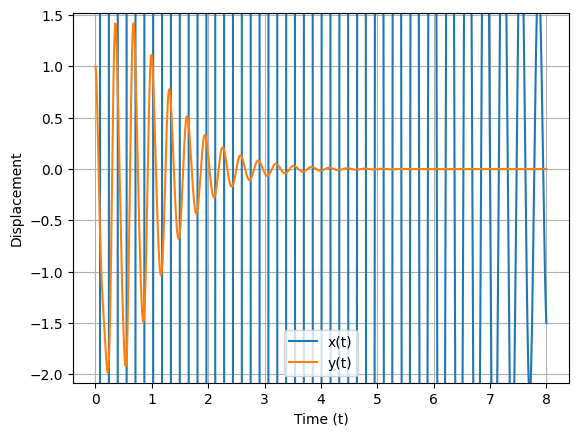

In [19]:
alpha = 0.1

# Coupled system of equations
def coupled_system(t, state):
    x1, x2, y1, y2 = state  # x, x', y, y'
    dx1_dt = x2
    dx2_dt = -2 * x2 - 400 * x1 - alpha * x1 * y1
    dy1_dt = y2
    dy2_dt = -3 * y2 - 400 * y1 - alpha * x1 * y1
    return [dx1_dt, dx2_dt, dy1_dt, dy2_dt]

# Initial conditions: x(0) = 10, x'(0) = 0, y(0) = 1, y'(0) = 0
initial_conditions = [5000, 0, 1, 0]

# Time span for simulation
t_span = (0, 8)
t = np.linspace(t_span[0], t_span[1], 1000)

# Solve the system using solve_ivp
solution = scipy.integrate.solve_ivp(coupled_system, t_span, initial_conditions, t_eval=t, method='RK45')

# Extract results
t = solution.t
x = solution.y[0]
y = solution.y[2]

# Plot x(t)
plt.plot(t, x, label='x(t)')

# Plot y(t)
plt.plot(t, y, label='y(t)')

# Titles and labels
plt.xlabel('Time (t)')
plt.ylabel('Displacement')
plt.ylim(min(y)-0.1, max(y)+0.1)
plt.legend()
plt.grid()

The view of the plot has been zoomed in on $y(t)$, since the behavior of $x(t)$ will simply be the same as before but starting at a larger displacement value and decaying for a longer amount of time. The other system will start at the same unit offset as before, but then oscillate with an amplitude higher than the initial value. This happens since the effect from the first system is so strong that the second system gains enough energy to oscillate past the initial value. This also results in the system decaying for a longer amount of time than before when both systems had an initial unit offset.

### 4. {-}
Finally, assume that the first system is driven by an external force

\begin{align*}
x'' + 2x' + 400x + \alpha xy &= \cos(20t)\\
y'' + 3y' + 400y + \alpha xy &= 0
\end{align*}

Again, compute and plot solutions for $x(t)$ and $y(t)$ for the $\alpha = 0.1$ case. Describe the effects of the external force on system 1.

The solution is again computed and plotted using python.

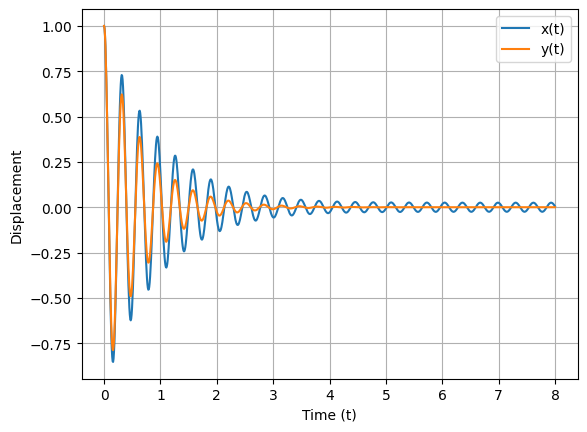

In [20]:
alpha = 0.1

# Coupled system of equations
def coupled_system(t, state):
    x1, x2, y1, y2 = state  # x, x', y, y'
    dx1_dt = x2
    dx2_dt = np.cos(20 * t) - 2 * x2 - 400 * x1 - alpha * x1 * y1
    dy1_dt = y2
    dy2_dt = -3 * y2 - 400 * y1 - alpha * x1 * y1
    return [dx1_dt, dx2_dt, dy1_dt, dy2_dt]

# Initial conditions: x(0) = 1, x'(0) = 0, y(0) = 1, y'(0) = 0
initial_conditions = [1, 0, 1, 0]

# Time span for simulation
t_span = (0, 8)
t = np.linspace(t_span[0], t_span[1], 1000)

# Solve the system using solve_ivp
solution = scipy.integrate.solve_ivp(coupled_system, t_span, initial_conditions, t_eval=t, method='RK45')

# Extract results
t = solution.t
x = solution.y[0]
y = solution.y[2]

# Plot x(t)
plt.plot(t, x, label='x(t)')

# Plot y(t)
plt.plot(t, y, label='y(t)')

# Titles and labels
plt.xlabel('Time (t)')
plt.ylabel('Displacement')
plt.legend()
plt.grid()

With the external force added, $x(t)$ no longer decays toward and equilibrium of 0 but decays to a sinusoid. This is due to the fact that $\cos(20t)$ is an external force that is resonant with the system, since it has a frequency that is equal to the systems natural frequency.

Following the Theorem 3.2.5 it is known that the solution to the system must be the sum of any particular solution as well as the solution to the associated homogeneous system. Since the homogeneous solution corresponds to the system with no external driving force, it is known that the solution must be transient and approaches a constant value of 0. The particular solution will then be the only non-zero component of the solution at larger value of $t$. Following the method of undetermined coefficients it is known that the particular solution must be a sinusoid, since the external force is described by a sinusoid. This explains why the plot of $x(t)$ decays to a sinusoid. 

The sinusoid that the system approaches is only small because the external force has a unit amplitude. If the amplitude of the external force was significantly larger than the damping constant (second term of the system), the sinusoid that the system approaches would be larger and potentially even oscillate past the initial value.

$\pagebreak$

## Problem 4 {-}
Consider the two-population system given by
$$
\frac{dx}{dt} = 30x − 2x^{2} − xy, \qquad \frac{dy}{dt} = 20y − 4y^{2} + 2xy
$$

### 1. {-}
Describe the type of x- and y-populations involved and the nature of their interaction.

The different terms of the system can be modelled after equation 6.3.7, which gives the following coefficients
$$
a_{1} = 30, \quad b_{1} = 2, \quad c_{1} = 1, \quad
$$
$$
a_{2} = 20, \quad b_{2} = 4, \quad c_{2} = -2
$$

Since $c_{1}$ and $c_{2}$ have different signs, the interaction between the two populations is a predation. Seeing as it is negative for the $x$-population it must be the prey, meaning that the $y$-population is the predator. In other words the $x$-population is the hurt by the growth of the $y$-population, while the growth of the $x$-population helps the $y$-population. Since the equations have second order terms (terms with $b$ coefficient), it means that both populations will exhibit logistic growth in the absence of the other population.

### 2. {-}
Find and characterize the system's critical points with respect to type and stability.

Rewriting the two systems to factor out $x$ and $y$ respectively yields
$$
\frac{dx}{dt} = x(30 − 2x − y), \qquad \frac{dy}{dt} = y(20 - 4y + 2x)
$$

It can now be seen that critical points must satisfy $x=0$ or $30 - 2x - y$ and $y=0$ or $20 - 4y + 2x$. Finding all permutations of this leads to the following critical points 
$$
(0,0), \quad (0,5), \quad (15,0), \quad (10,10)
$$

The Jacobian matrix of the system can be found as the following

\begin{align*}
\textbf{J}(x,y) &= \begin{bmatrix}
\frac{\partial}{\partial x} 30x - 2x^{2} - xy & \frac{\partial}{\partial y} 30x - 2x^{2} - xy\\
\frac{\partial}{\partial x} 20y - 4y^{2} + 2xy & \frac{\partial}{\partial y} 20y - 4y^{2} + 2xy
\end{bmatrix}\\
&= \begin{bmatrix}
30 - 4x - y & -x \\
2y & 20 - 8y + 2x
\end{bmatrix}
\end{align*}

Inserting the critical point $(0,0)$ into this matrix yields

\begin{align*}
\textbf{J}(x,y) &= \begin{bmatrix}
30 - 4 \cdot 0 - 0 & -0 \\
2 \cdot 0 & 20 - 8 \cdot 0 + 2 \cdot 0
\end{bmatrix}\\
&= \begin{bmatrix}
30 & 0 \\
0 & 20
\end{bmatrix}
\end{align*}

Using python the eigenvalues for this matrix is computed to be

In [21]:
A = sp.Matrix([ [30, 0],
                [0, 20]])

vals = list(A.eigenvals().keys())
print(vals[0], "and", vals[1])

30 and 20


Based on figure 6.2.7, it can be reasoned that since both eigenvalues are positive and real, the critical point $(0,0)$ must be an unstable improper node.

Inserting the critical point $(0,5)$ yields

\begin{align*}
\textbf{J}(x,y) &= \begin{bmatrix}
30 - 4 \cdot 0 - 5 & -0 \\
2 \cdot 5 & 20 - 8 \cdot 5 + 2 \cdot 0
\end{bmatrix}\\
&= \begin{bmatrix}
25 & 0 \\
10 & -20
\end{bmatrix}
\end{align*}

The corresponding eigenvalues are

In [22]:
A = sp.Matrix([ [25, 0],
                [10, -20]])

vals = list(A.eigenvals().keys())
print(vals[0], "and", vals[1])

25 and -20


Since the one of the eigenvalues is positive and real while the other is negative and real, the critical point $(0,5)$ must be an unstable saddle point.

Inserting the critical point $(15,0)$ yields

\begin{align*}
\textbf{J}(x,y) &= \begin{bmatrix}
30 - 4 \cdot 15 - 0 & -15 \\
2 \cdot 0 & 20 - 8 \cdot 0 + 2 \cdot 15
\end{bmatrix}\\
&= \begin{bmatrix}
-30 & -15 \\
0 & 50
\end{bmatrix}
\end{align*}

The corresponding eigenvalues are

In [23]:
A = sp.Matrix([ [-30, -15],
                [0, 50]])

vals = list(A.eigenvals().keys())
print(vals[0], "and", vals[1])

50 and -30


Again the eigenvalues are real with one positive and one negative. This means that the critical point $(15,0)$ must also be an unstable saddle point.

Lastly inserting the critical point $(10,10)$ yields

\begin{align*}
\textbf{J}(x,y) &= \begin{bmatrix}
30 - 4 \cdot 10 - 10 & -10 \\
2 \cdot 10 & 20 - 8 \cdot 10 + 2 \cdot 10
\end{bmatrix}\\
&= \begin{bmatrix}
-20 & -10 \\
20 & -40
\end{bmatrix}
\end{align*}

The corresponding eigenvalues are

In [24]:
A = sp.Matrix([ [-20, -10],
                [20, -40]])

vals = list(A.eigenvals().keys())
display(vals[0])
print("and")
display(vals[1])

-30 - 10*I

and


-30 + 10*I

In this case both eigenvalues are complex with only negative real parts. This mean that the critical point $(10,10)$ must be a stable spiral point.

### 3. {-}
Determine what nonzero x- and y-populations can coexist.

The critical point which represents the possibility of coexistence of the two populations is $(10,10)$, since this is the only critical point where both populations are at a nonzero equilibrium. The coefficients representing the inhibition ($b$) and competition ($c$) of the system can be analyzed to see whether the populations can coexist. Inserting these into the inequality of equation 6.3.9 leads to
$$
c_{1} c_{2} = -2 < 8 = b_{1} b_{2}
$$

This falls into the case where the competition between the populations is smaller than the inhibition which means that the populations can and do coexist. This conclusion also makes sense since the critical point was previously analyzed to be a stable critical point and not an unstable one.

### 4. {-}
Construct a phase-plane portrait and describe the long-term behaviour of the two populations in terms of their initial populations $x(0)$ and $y(0)$.

The phase-plane portrait is constructed using python and plotted along with the four critical points, which can be seen below

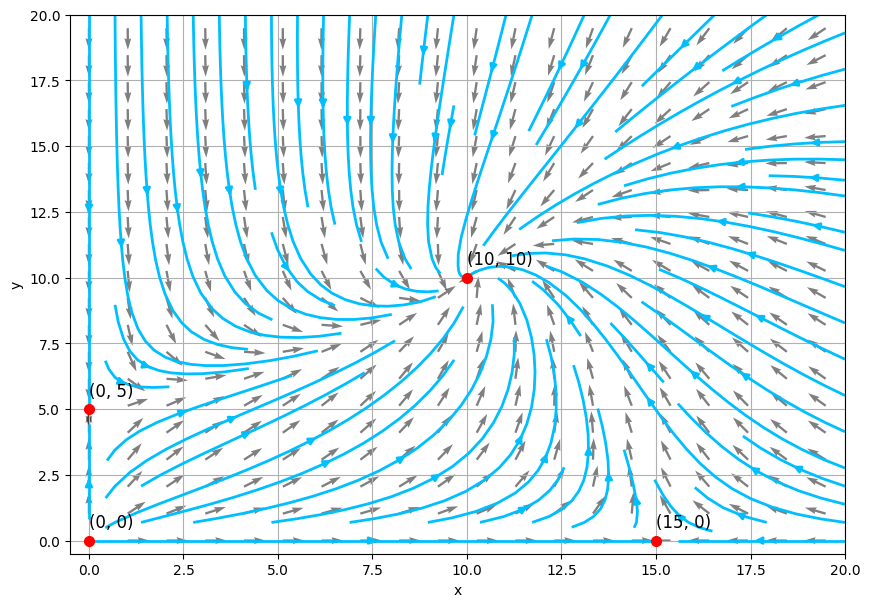

In [32]:
# Define the system of differential equations
def system(state, t):
    x, y = state
    dxdt = 30 * x - 2 * x**2 - x * y
    dydt = 20 * y - 4 * y**2 + 2 * x * y
    return [dxdt, dydt]

# Create a grid of points
x = np.linspace(0, 20, 40)
y = np.linspace(0, 20, 40)
X, Y = np.meshgrid(x, y)

# Compute the direction field
U = 30 * X - 2 * X**2 - X * Y
V = 20 * Y - 4 * Y**2 + 2 * X * Y

# Normalize the arrows for the quiver plot
magnitude = np.sqrt(U**2 + V**2)
magnitude[magnitude == 0] = 1e-9
U /= magnitude
V /= magnitude
skip = (slice(None, None, 2), slice(None, None, 2))

# Plot the vector field
plt.figure(figsize=(10, 7))
plt.quiver(X[skip], Y[skip], U[skip], V[skip], alpha=0.5)
plt.streamplot(X, Y, U, V, density=1, linewidth=2, color="deepskyblue")

# Plot Critical Points
x = [0, 0, 15, 10]
y = [0, 5, 0, 10]

plt.plot(x, y, 'ro', markersize=7)

for i, j in zip(x, y):
   plt.text(i, j+0.5, f'({i}, {j})', size="large")

# Customize the plot
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(-0.5, 20)
plt.ylim(-0.5, 20)
plt.grid()
plt.show()

$\pagebreak$

The negative x and y values are not plotted or discussed here since negative population does not make sense. It is visually apparent in the plot, that the critical point $(10,10)$ is a stable spiral point since almost every trajectory asymptotically approaches said point as $t \to \infty$. This also clearly shows that for most initial populations, neither population will go extinct and they can coexist. 

The only trajectories which do not approach $(10,10)$ are those which approach the unstable saddle points $(0,5)$ and $(15,0)$. The trajectories that lead to these points are very slim since they are unstable points. They can therefore be seen as the separatrixes of the system. The separatrixes can be seen highlighted in black below, where the vertical line highlights the trajectory towards $(0,5)$ and the horizontal line highlights the trajectory towards $(15,0)$. Any initial value that does not land on the separatrixes can be described as being in Region I even though there will only be one region and will approach $(10,10)$.

Since $(10,10)$ describes coexistence, the separatrix describes existence of one population but not the other, which in the long still only leads to one population since the other never existed. There is a last edge case where no population ever existed, which is the described by the last critical point $(0,0)$.

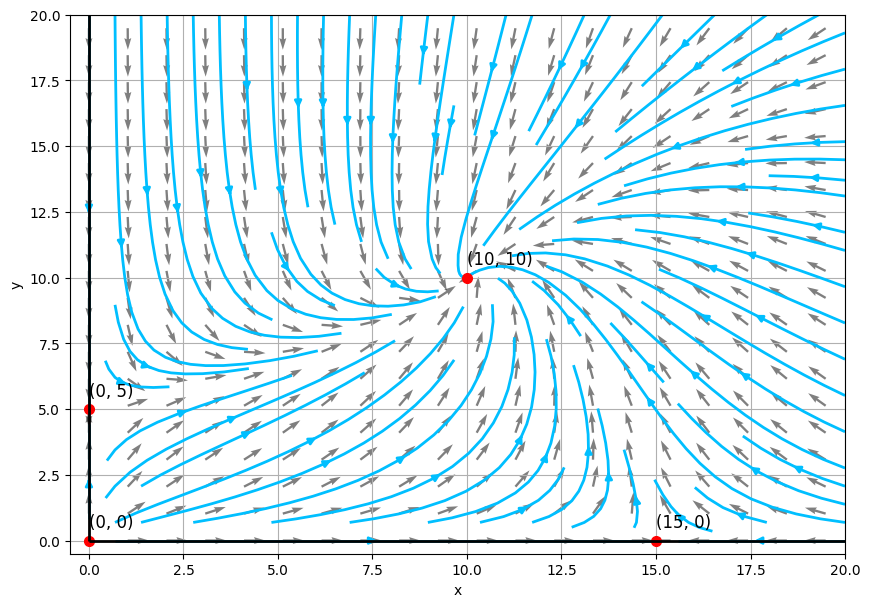

In [26]:
# Plot the vector field
plt.figure(figsize=(10, 7))
plt.quiver(X[skip], Y[skip], U[skip], V[skip], alpha=0.5)
plt.streamplot(X, Y, U, V, density=1, linewidth=2, color="deepskyblue")

# Plot Critical Points
plt.plot(x, y, 'ro', markersize=7)

for i, j in zip(x, y):
   plt.text(i, j+0.5, f'({i}, {j})', size="large")

plt.vlines(0, 0, 20, colors='b', label='x = 5', color="black", linewidth=2)
plt.hlines(0, 0, 20, colors='b', label='x = 5', color="black", linewidth=2)

# Customize the plot
plt.xlabel("x")
plt.ylabel("y")
plt.xlim(-0.5, 20)
plt.ylim(-0.5, 20)
plt.grid()
plt.show()